<a href="https://colab.research.google.com/github/dwaipayan05/CovCNN-WebApp/blob/main/COVID_Chest_X_Ray_(VGG16).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import os

# Point directly to your dataset folder on Windows
dataset_path = r"S:\CovCNN-WebApp\Dataset"
os.chdir(dataset_path)
print("Current working directory:", os.getcwd())


Current working directory: S:\CovCNN-WebApp\Dataset


**Import Necessary Libraries**

In [6]:
import os
import pandas as pd
import numpy as np
from tqdm import tqdm
import keras
from keras.utils import to_categorical
import cv2
import tensorflow as tf
from sklearn.model_selection import train_test_split
from keras.layers import  Flatten, Dense, Dropout
from keras.applications import VGG16
from keras.models import Model
from keras import optimizers
from keras.optimizers import Adam
from keras.layers import Dense, GlobalAveragePooling2D
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D, BatchNormalization, AveragePooling2D, GlobalAveragePooling2D
import keras_preprocessing
from keras_preprocessing import image
from keras_preprocessing.image import ImageDataGenerator
from keras import callbacks
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [8]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU Device Name:", tf.test.gpu_device_name())
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))


TensorFlow version: 2.20.0
GPU Device Name: 
Num GPUs Available: 0


In [9]:
import os

# change to your dataset folder
os.chdir(r"S:\CovCNN-WebApp\Dataset")

# verify
print("Current directory:", os.getcwd())


Current directory: S:\CovCNN-WebApp\Dataset


**Fetch Dataset**

In [12]:
import os

# Change directory to your dataset
data_dir = r"S:\CovCNN-WebApp\Dataset"
os.chdir(data_dir)

print("✅ Current directory set to:", os.getcwd())

# Check folder structure
print("Folders inside dataset:")
print(os.listdir())


✅ Current directory set to: S:\CovCNN-WebApp\Dataset
Folders inside dataset:
['COVID', 'non-COVID', 'ResNet50_Model.keras']


**Split Into Train Data & Test Data**

In [15]:
disease_types=['COVID', 'non-COVID']
data_dir = r"S:\CovCNN-WebApp\Dataset"
train_dir = data_dir
train_dir = os.path.join(data_dir)

In [16]:
train_data = []
for defects_id, sp in enumerate(disease_types):
    for file in os.listdir(os.path.join(train_dir, sp)):
        train_data.append(['{}/{}'.format(sp, file), defects_id, sp])      
train = pd.DataFrame(train_data, columns=['File', 'DiseaseID','Disease Type'])

In [17]:
IMAGE_SIZE = 150
def read_image(filepath):
    return cv2.imread(os.path.join(data_dir, filepath)) 
def resize_image(image, image_size):
    return cv2.resize(image.copy(), image_size, interpolation=cv2.INTER_AREA)

In [18]:
X_train = np.zeros((train.shape[0], IMAGE_SIZE, IMAGE_SIZE, 3))
for i, file in tqdm(enumerate(train['File'].values)):
    image = read_image(file)
    if image is not None:
        X_train[i] = resize_image(image, (IMAGE_SIZE, IMAGE_SIZE))
X_Train = X_train / 255.
print(X_Train.shape)

2481it [00:27, 89.34it/s]


(2481, 150, 150, 3)


In [19]:
Y_train = train['DiseaseID'].values
Y_train = to_categorical(Y_train, num_classes=2)

In [20]:
X_train, X_val, Y_train, Y_val = train_test_split(X_Train, Y_train, test_size=0.1)

**Define VGG16 Model Architecture**

In [22]:
vgg16_model = VGG16(weights = 'imagenet', include_top = False,input_shape=(150,150,3))
x = vgg16_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)

predictions = Dense(2, activation = 'softmax')(x)
model = Model(vgg16_model.input,predictions)
for layer in vgg16_model.layers:
    layer.trainable = False
optimizer = Adam(learning_rate=0.0002)
model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])
model._name = "VGG16_Architecture"
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,02

 Total params: 14,849,602 (56.65 MB)

 Trainable params: 133,378 (521.01 KB)

 Non-trainable params: 14,716,224 (56.14 MB)

**Train the Model**

In [25]:
training_datagen = ImageDataGenerator(rotation_range=40, 
                        width_shift_range=0.2, 
                        height_shift_range=0.2, 
                        zoom_range=0.2, 
                        horizontal_flip=True, 
                        vertical_flip=True,
                        shear_range=0.2) 

train_generator = training_datagen.flow(
	X_train, Y_train,
batch_size=64
)
training_datagen.fit(X_train)


filepath = "VGG16_Model.keras"
checkpoint = callbacks.ModelCheckpoint(filepath, monitor='val_loss',save_best_only=True, mode='min',verbose=1)
callbacks_list = [checkpoint]

history = model.fit(
    train_generator,
    steps_per_epoch=32,
    epochs=200,
    validation_data=(X_val, Y_val),
    validation_steps=50,
    callbacks=callbacks_list
)


C:\Users\ASIF\AppData\Roaming\Python\Python313\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5279 - loss: 1.0158
Epoch 1: val_loss improved from None to 0.66774, saving model to VGG16_Model.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 53s 2s/step - accuracy: 0.5574 - loss: 0.9573 - val_accuracy: 0.5863 - val_loss: 0.6677
Epoch 2/200
 3/32 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.5851 - loss: 0.9836

C:\Users\ASIF\AppData\Roaming\Python\Python313\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_loss improved from 0.66774 to 0.66529, saving model to VGG16_Model.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 302ms/step - accuracy: 0.5677 - loss: 1.0027 - val_accuracy: 0.6145 - val_loss: 0.6653
Epoch 3/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6333 - loss: 0.8612
Epoch 3: val_loss improved from 0.66529 to 0.64470, saving model to VGG16_Model.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 64s 2s/step - accuracy: 0.6475 - loss: 0.8276 - val_accuracy: 0.6506 - val_loss: 0.6447
Epoch 4/200
 3/32 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step - accuracy: 0.6649 - loss: 0.7595
Epoch 4: val_loss improved from 0.64470 to 0.64345, saving model to VGG16_Model.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 352ms/step - accuracy: 0.6667 - loss: 0.7721 - val_accuracy: 0.6466 - val_loss: 0.6435
Epoch 5/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6714 - loss: 0.7639
Epoch 5: val_loss improved from 0.64345 to 0.62852, saving model to VGG16_Model.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 60s 2s/step - accuracy: 

**Plot the Results**

In [26]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

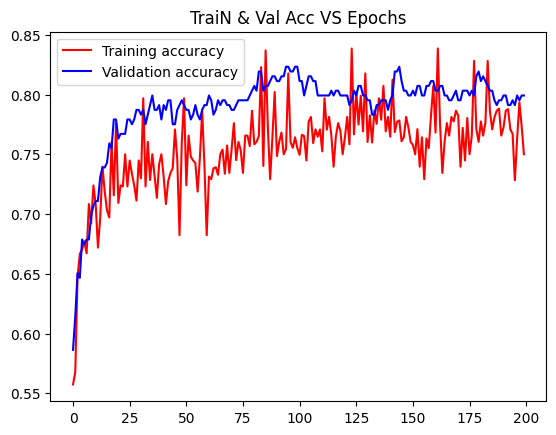

<Figure size 640x480 with 0 Axes>

In [27]:
epochs = range(len(acc))
plt.plot(epochs, acc, 'r', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('TraiN & Val Acc VS Epochs')
plt.legend(loc=0)
plt.figure()
plt.show()

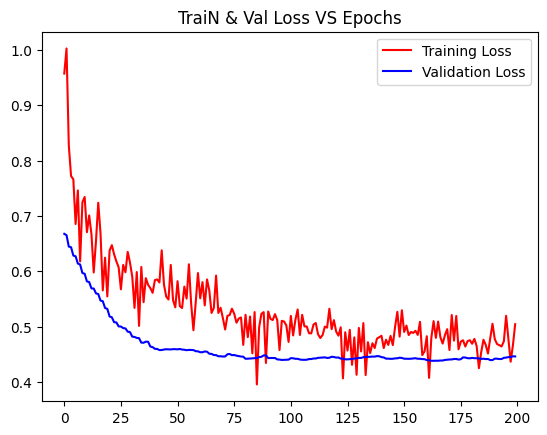

<Figure size 640x480 with 0 Axes>

In [28]:
epochs = range(len(acc))
plt.plot(epochs, loss, 'r', label='Training Loss')
plt.plot(epochs, val_loss, 'b', label='Validation Loss')
plt.title('TraiN & Val Loss VS Epochs')
plt.legend(loc=0)
plt.figure()
plt.show()

In [30]:
model.load_weights("VGG16_Model.keras")
score = model.evaluate(X_val, Y_val, verbose=1)
print('Test Loss:', score[0])
print('Test Accuracy:', score[1] * 100)


8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 778ms/step - accuracy: 0.8072 - loss: 0.4383
Test Loss: 0.4382951557636261
Test Accuracy: 80.72289228439331


8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 803ms/step


Text(0.5, 1.0, 'Confusion Matrix')

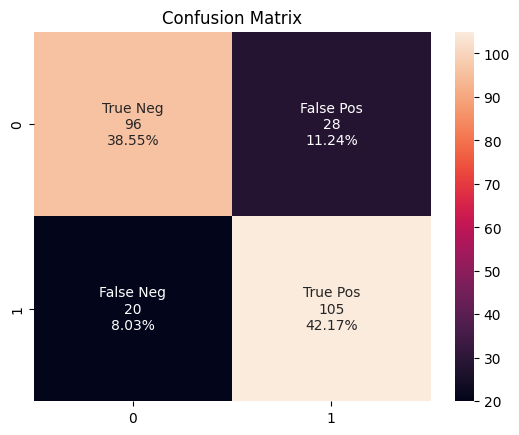

In [31]:
Y_pred = model.predict(X_val)
Y_predx = np.argmax(Y_pred, axis = -1)
Y_valx = np.argmax(Y_val, axis = -1)
cf_matrix = confusion_matrix(Y_valx, Y_predx)
group_names = ['True Neg','False Pos','False Neg','True Pos']
group_counts = ["{0:0.0f}".format(value) for value in
                cf_matrix.flatten()]
group_percentages = ["{0:.2%}".format(value) for value in
                     cf_matrix.flatten()/np.sum(cf_matrix)]
labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in
          zip(group_names,group_counts,group_percentages)]
labels = np.asarray(labels).reshape(2,2)
sns.heatmap(cf_matrix, annot = labels, fmt = '')
plt.title("Confusion Matrix")